# Import dependencies

In [1]:
import sys
import os
import pickle
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from scipy import stats

sys.path.append(os.path.abspath(".."))
from utils import evaluate_model, find_optimal_threshold, plot_evaluation, METRIC_TARGETS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

### Let's predict ride cancellations based on trip and customer features using Logistic Regression

# Data Loading

In [2]:
data_dir = "../data/silver"

X_train = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
X_val = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
X_test = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

y_train = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))['is_cancelled']
y_val = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))['is_cancelled']
y_test = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))['is_cancelled']

split_info = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    "cancel_rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})
split_info

,split,rows,features,cancel_rate
0,Train,112705,18,0.320855
1,Validation,25045,18,0.316630
2,Test,12250,18,0.319020


# Data Preprocessing

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Baseline Model

In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_scaled, y_train)

y_dummy_pred = dummy.predict(X_val_scaled)
y_dummy_prob = dummy.predict_proba(X_val_scaled)[:, 1] if hasattr(dummy, "predict_proba") else np.zeros(len(y_val))

dummy_metrics = pd.DataFrame([{
    "model": "DummyClassifier (most_frequent)",
    "f2": fbeta_score(y_val, y_dummy_pred, beta=2),
    "f1": f1_score(y_val, y_dummy_pred, zero_division=0),
    "precision": precision_score(y_val, y_dummy_pred, zero_division=0),
    "recall": recall_score(y_val, y_dummy_pred, zero_division=0),
}])
dummy_metrics

,model,f2,f1,precision,recall
0,DummyClassifier (most_frequent),0.0,0.0,0.0,0.0


The dummy classifier just predicts the majority class every time so recall and F2 are both zero. Any real model needs to beat this floor, which shouldn't be hard, but it's a useful sanity check to have the numbers written down.

# Model Training

In [5]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

model.fit(X_train_scaled, y_train)

y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [6]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
2,is_high_vtat,0.524006,0.524006
0,avg_vtat_imputed,-0.218633,0.218633
1,vtat_bucket,0.156979,0.156979
9,is_weekend,-0.017316,0.017316
3,pickup_encoded,0.015462,0.015462
7,dayofweek,0.014824,0.014824
4,drop_encoded,0.014511,0.014511
15,dow_cos,0.011718,0.011718
8,month,0.007396,0.007396
16,month_sin,-0.007037,0.007037


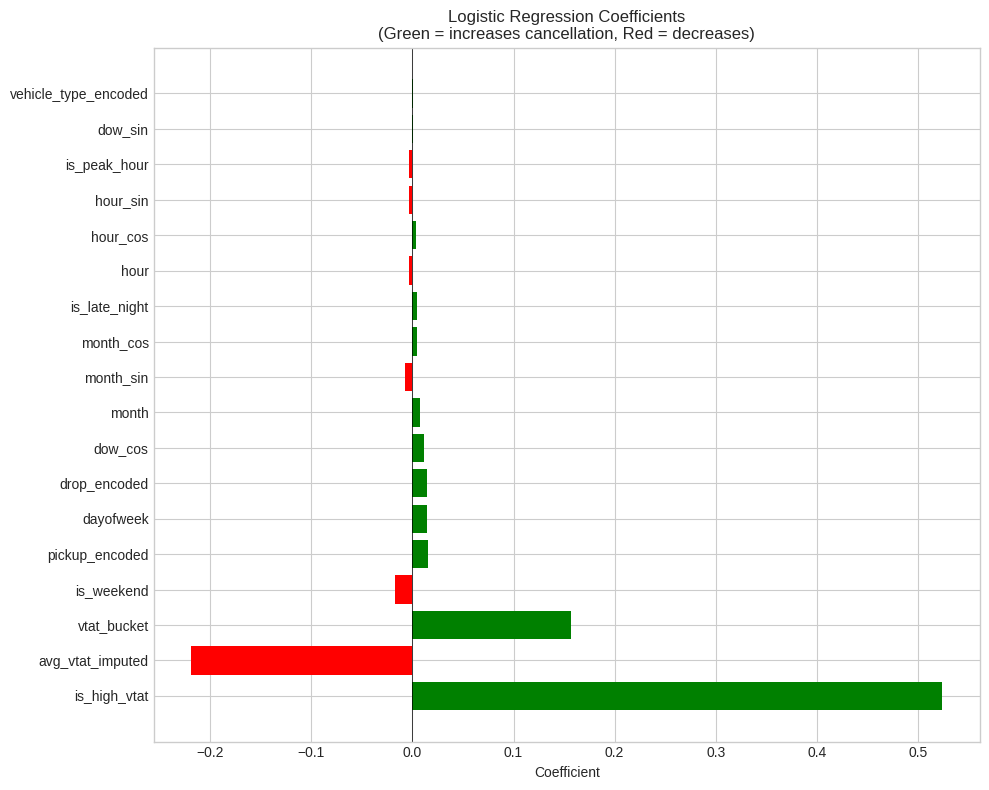

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['green' if c > 0 else 'red' for c in feature_importance['coefficient']]
ax.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Coefficients\n(Green = increases cancellation, Red = decreases)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Assumption Validation

In [8]:
n_events = y_train.sum()
n_features = X_train.shape[1]
epv = n_events / n_features

epv_df = pd.DataFrame([{
    "positive_cases": int(n_events),
    "features": n_features,
    "events_per_variable": round(epv, 1),
    "rule_of_thumb (>=10)": "PASS" if epv >= 10 else "FAIL"
}])
epv_df

,positive_cases,features,events_per_variable,rule_of_thumb (>=10)
0,36162,18,2009.0,PASS


The events-per-variable ratio tells us whether we have enough positive cases relative to the number of predictors. A ratio above 10 is the classic rule of thumb for logistic regression to produce stable estimates. If this passes comfortably we don't need to worry about overfitting from too many features.

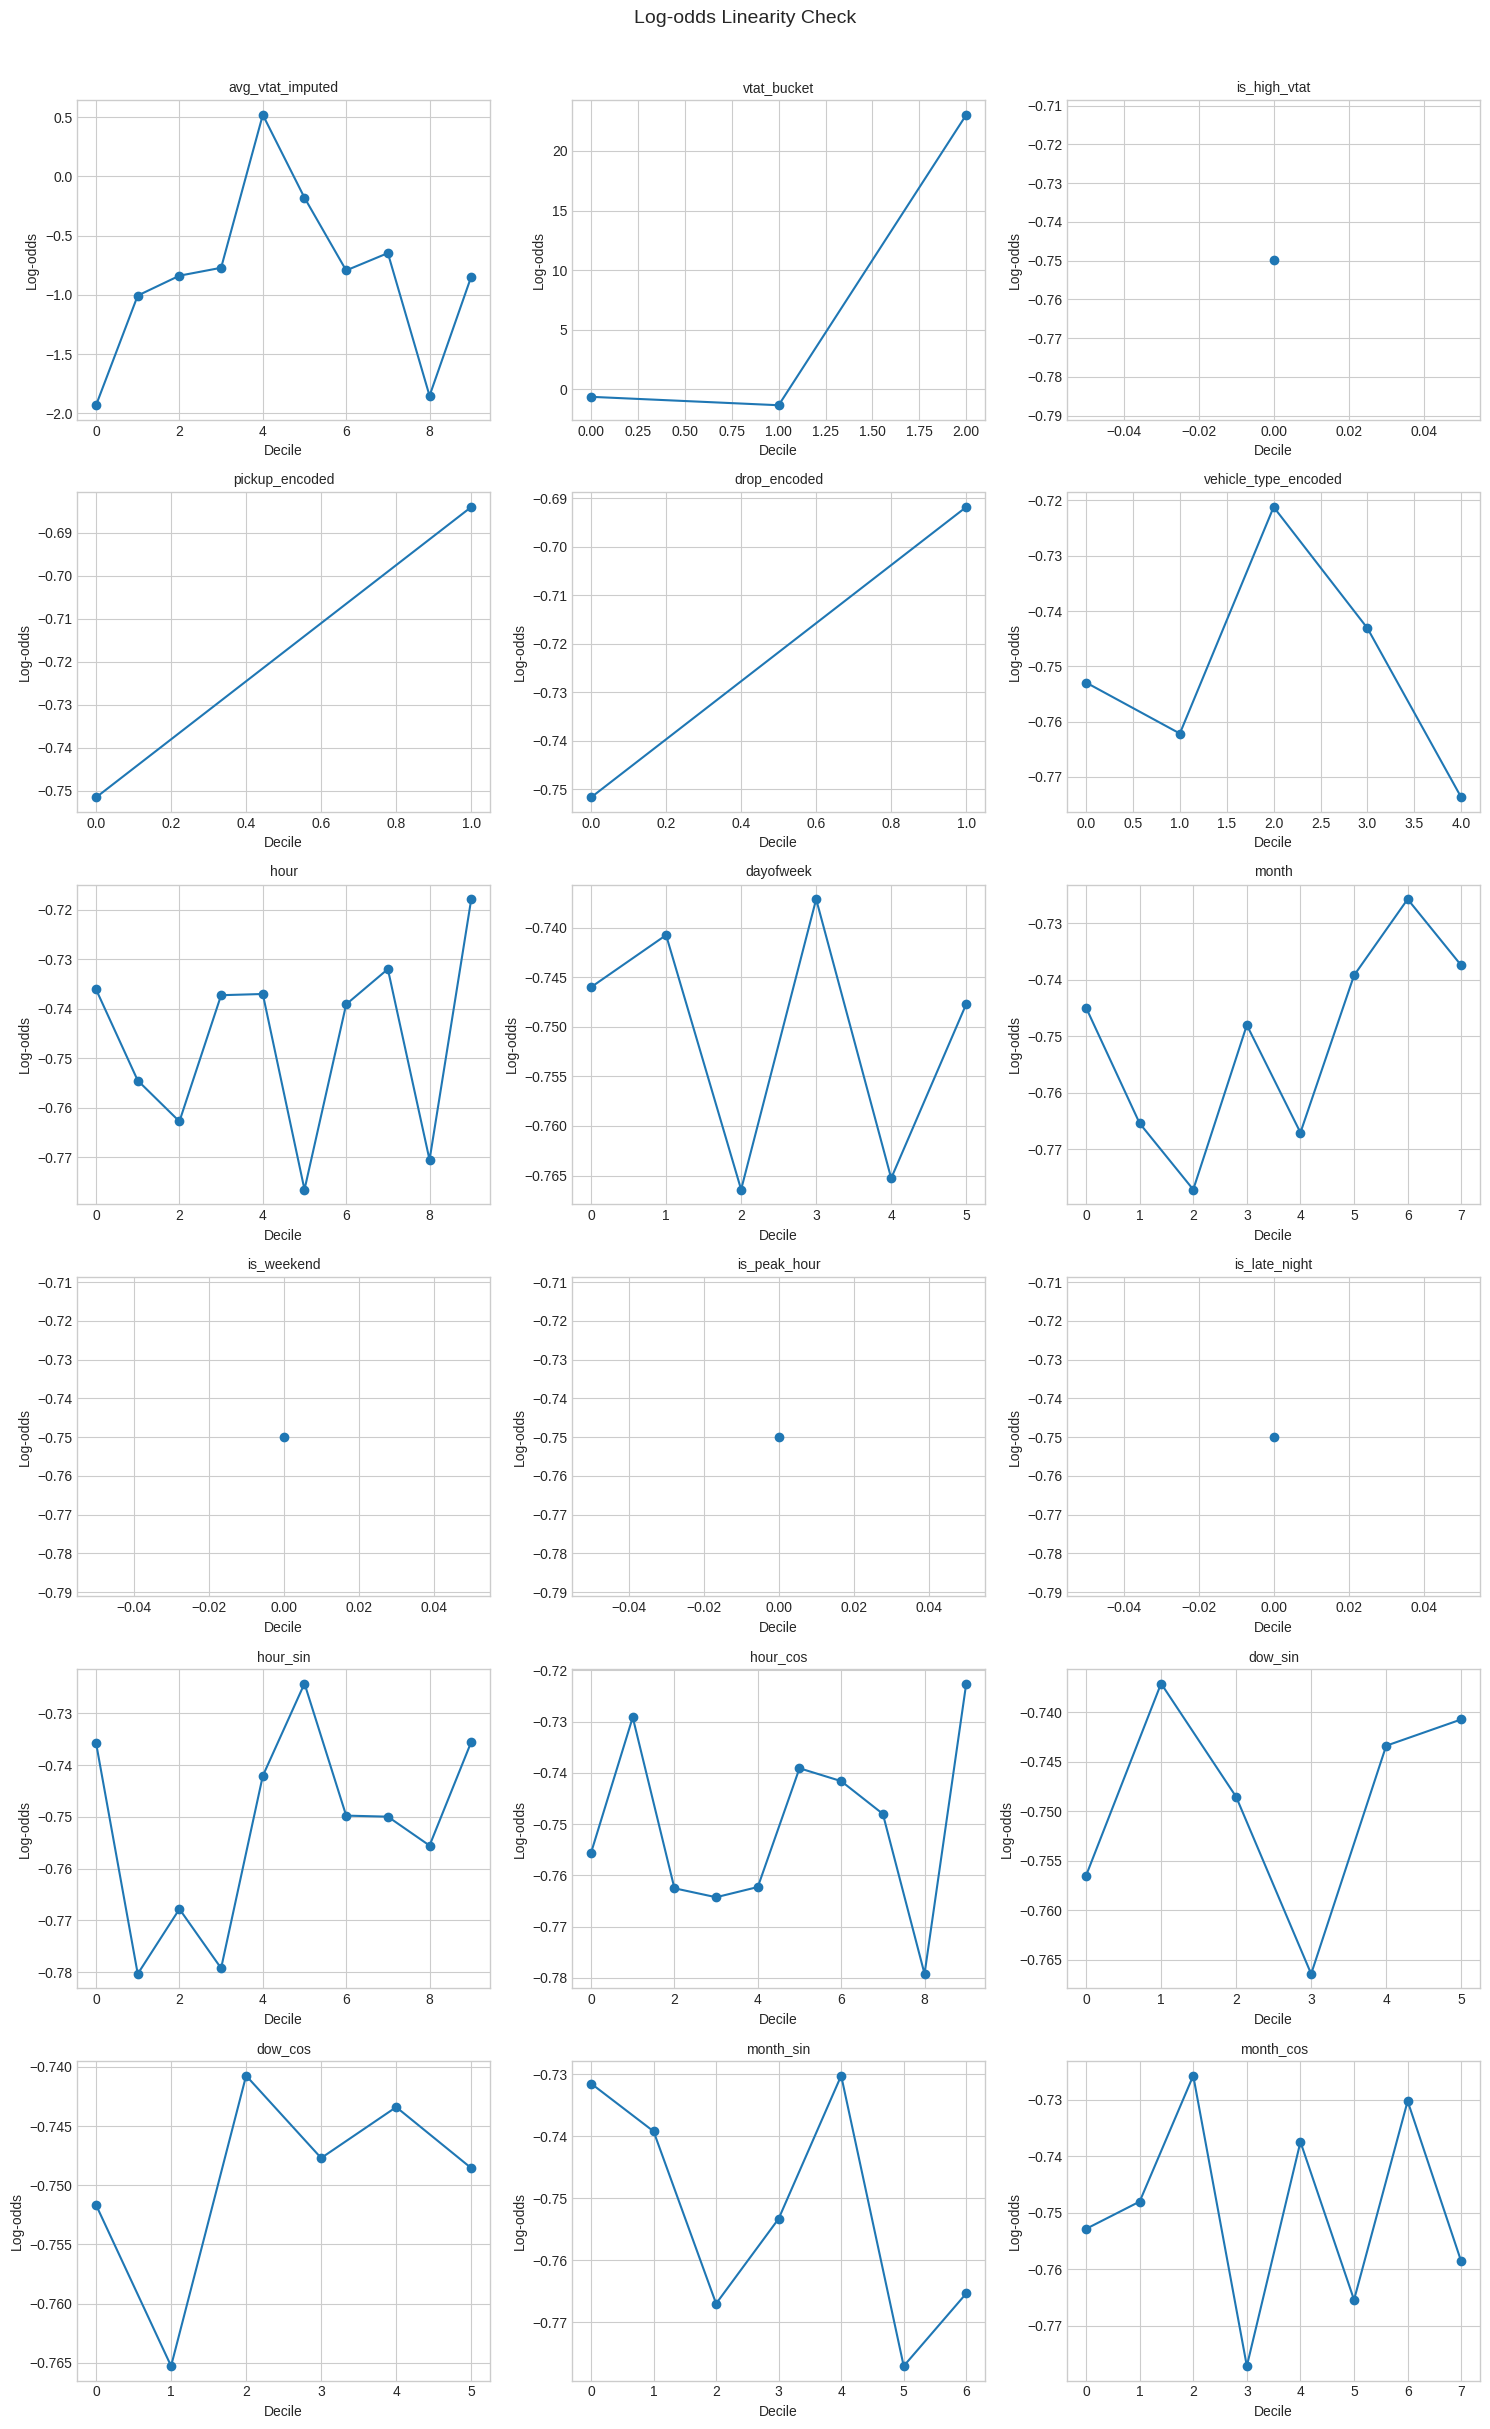

In [9]:
numeric_features = X_train.columns.tolist()
n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, feat in enumerate(numeric_features):
    col_vals = X_train[feat]
    bins = pd.qcut(col_vals, q=10, duplicates='drop')
    grouped = pd.DataFrame({'feature': col_vals, 'target': y_train, 'bin': bins})
    bin_stats = grouped.groupby('bin', observed=True)['target'].mean()
    log_odds = np.log(bin_stats / (1 - bin_stats + 1e-10))

    axes[idx].plot(range(len(log_odds)), log_odds.values, 'o-')
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].set_xlabel('Decile')
    axes[idx].set_ylabel('Log-odds')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Log-odds Linearity Check', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The log-odds plots show how the relationship between each feature and the target looks in logit space. Logistic regression assumes this is roughly linear. Features that show a clear monotone trend are well-suited to the model. Any that curve heavily or flip direction might benefit from a polynomial term or binning, but for a baseline we'll leave them as-is and revisit if needed.

# Evaluation

## Default Threshold (0.5)


EVALUATION RESULTS - Validation (threshold=0.5)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.3296  | ≥ 0.68  | ❌
Recall          | 0.3361  | ≥ 0.70  | ❌
Precision       | 0.3060  | ≥ 0.60  | ❌
F1-Score        | 0.3203  |         |
PR-AUC          | 0.3969  |         |
ROC-AUC         | 0.5429  |         |


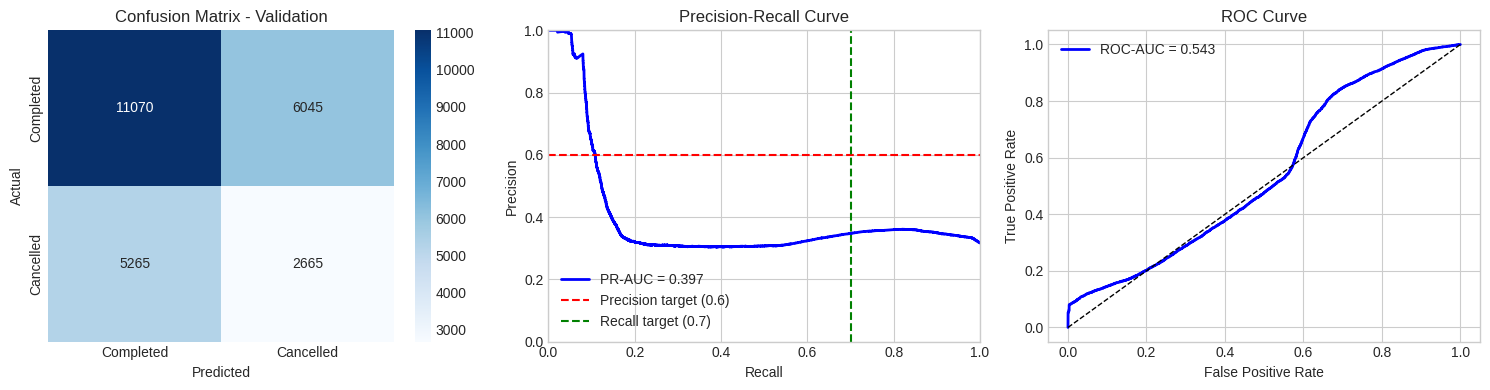

In [10]:
val_metrics = evaluate_model(y_val, y_val_pred, y_val_prob, "Validation (threshold=0.5)")
plot_evaluation(y_val, y_val_pred, y_val_prob, "Validation")

## Threshold Optimization

In [11]:
optimal_threshold, best_f2, threshold_results = find_optimal_threshold(y_val, y_val_prob, beta=2)

threshold_summary = pd.DataFrame([{
    "optimal_threshold": round(optimal_threshold, 2),
    "best_f2": round(best_f2, 4)
}])
threshold_summary

,optimal_threshold,best_f2
0,0.45,0.7053


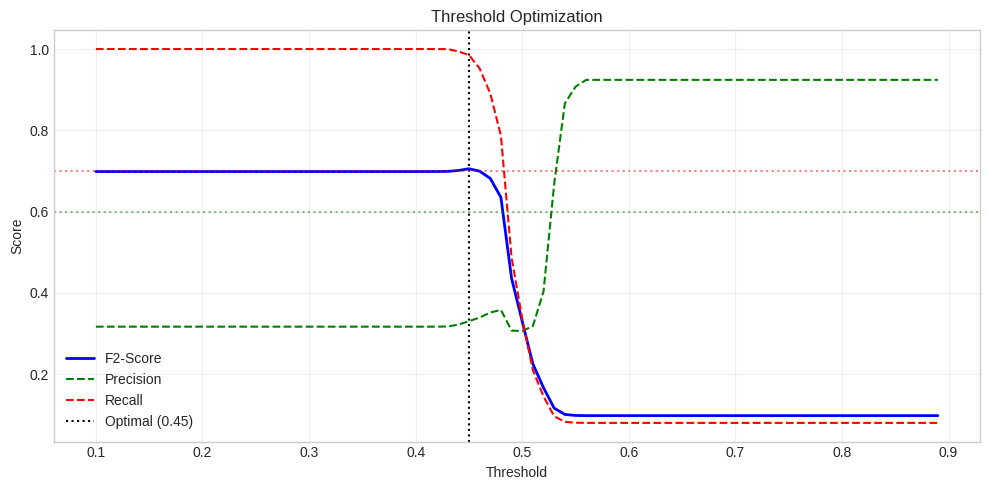

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_results['threshold'], threshold_results['f_beta'], 'b-', label='F2-Score', linewidth=2)
ax.plot(threshold_results['threshold'], threshold_results['precision'], 'g--', label='Precision')
ax.plot(threshold_results['threshold'], threshold_results['recall'], 'r--', label='Recall')
ax.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal ({optimal_threshold:.2f})')
ax.axhline(y=METRIC_TARGETS['recall'], color='r', linestyle=':', alpha=0.5)
ax.axhline(y=METRIC_TARGETS['precision'], color='g', linestyle=':', alpha=0.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Optimal Threshold


EVALUATION RESULTS - Validation (threshold=0.45)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.7053  | ≥ 0.68  | ✅
Recall          | 0.9851  | ≥ 0.70  | ✅
Precision       | 0.3302  | ≥ 0.60  | ❌
F1-Score        | 0.4946  |         |
PR-AUC          | 0.3969  |         |
ROC-AUC         | 0.5429  |         |


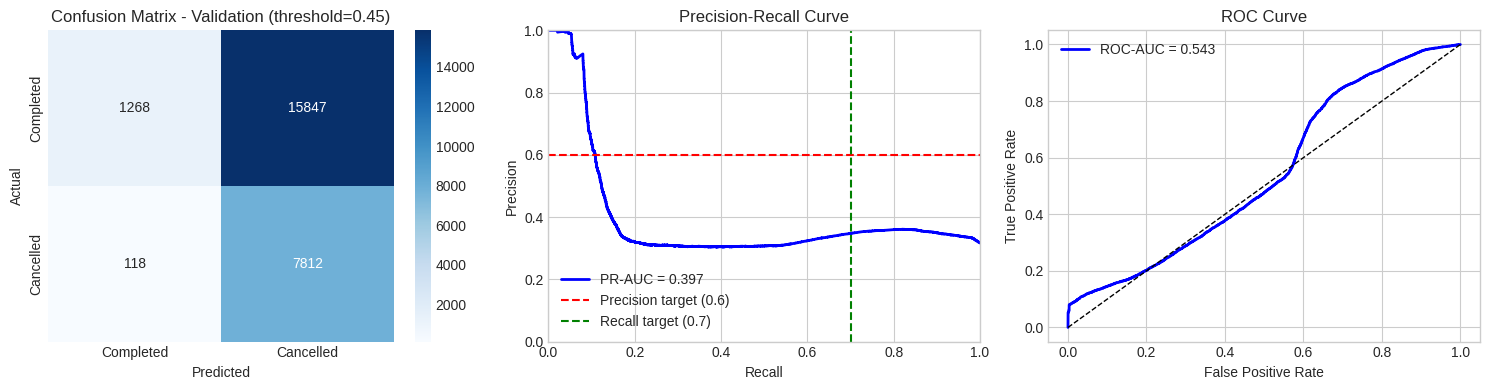

In [13]:
y_val_pred_opt = (y_val_prob >= optimal_threshold).astype(int)
y_test_pred_opt = (y_test_prob >= optimal_threshold).astype(int)

val_metrics_opt = evaluate_model(y_val, y_val_pred_opt, y_val_prob, f"Validation (threshold={optimal_threshold:.2f})")
plot_evaluation(y_val, y_val_pred_opt, y_val_prob, f"Validation (threshold={optimal_threshold:.2f})")


EVALUATION RESULTS - TEST SET (threshold=0.45)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.7052  | ≥ 0.68  | ✅
Recall          | 0.9821  | ≥ 0.70  | ✅
Precision       | 0.3315  | ≥ 0.60  | ❌
F1-Score        | 0.4956  |         |
PR-AUC          | 0.3902  |         |
ROC-AUC         | 0.5385  |         |


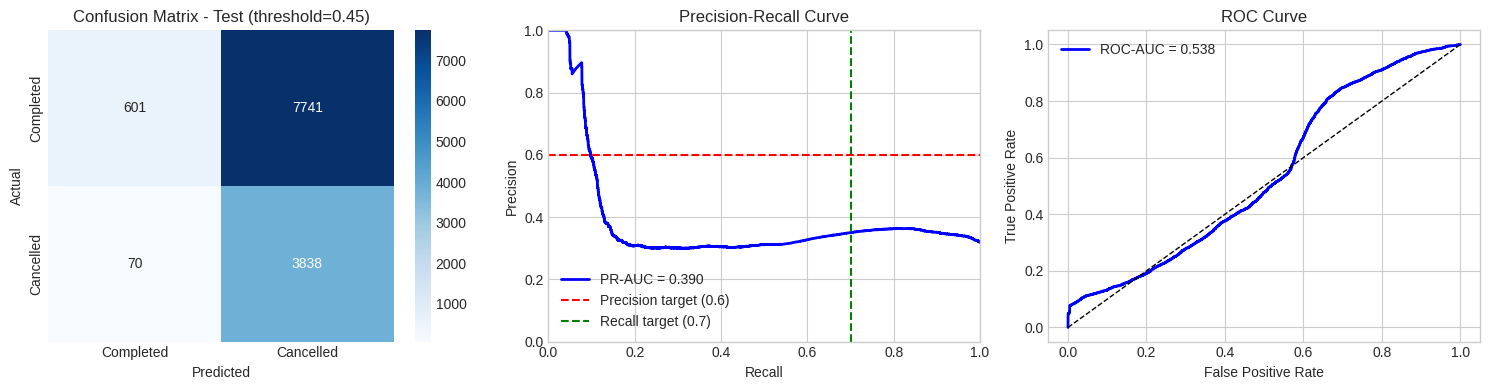

In [14]:
test_metrics = evaluate_model(y_test, y_test_pred_opt, y_test_prob, f"TEST SET (threshold={optimal_threshold:.2f})")
plot_evaluation(y_test, y_test_pred_opt, y_test_prob, f"Test (threshold={optimal_threshold:.2f})")

Compare the validation and test numbers side by side. If they're close the model generalizes well. A big gap in recall or F2 between val and test would suggest the threshold was overfit to validation data, which is something to watch for with more complex models later.

# Cross-Validation

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

scaler_cv = StandardScaler()
X_full_scaled = scaler_cv.fit_transform(X_full)

cv_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

cv_results = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_full_scaled, y_full), 1):
    cv_model.fit(X_full_scaled[train_idx], y_full.iloc[train_idx])
    y_cv_pred = cv_model.predict(X_full_scaled[val_idx])
    y_cv_prob = cv_model.predict_proba(X_full_scaled[val_idx])[:, 1]
    y_cv_pred_opt = (y_cv_prob >= optimal_threshold).astype(int)

    cv_results.append({
        "fold": fold,
        "f2": fbeta_score(y_full.iloc[val_idx], y_cv_pred_opt, beta=2),
        "f1": f1_score(y_full.iloc[val_idx], y_cv_pred_opt),
        "precision": precision_score(y_full.iloc[val_idx], y_cv_pred_opt),
        "recall": recall_score(y_full.iloc[val_idx], y_cv_pred_opt),
        "roc_auc": roc_auc_score(y_full.iloc[val_idx], y_cv_prob),
    })

cv_df = pd.DataFrame(cv_results)
cv_summary = cv_df.describe().loc[['mean', 'std']].T
cv_summary.columns = ['mean', 'std']
cv_summary

,mean,std
fold,3.000000,1.581139
f2,0.704975,0.002610
f1,0.503600,0.000749
precision,0.341177,0.000929
recall,0.961240,0.007269
roc_auc,0.540465,0.004047


Cross-validation gives a better picture of how stable the model is across different data splits. Low standard deviations mean the performance isn't just an artifact of one lucky train/val partition. If any single fold is way off from the rest that's a sign something weird is going on with a subset of the data.

# Summary

In [16]:
summary = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_metrics.iloc[0].to_dict()},
    {"model": f"LogReg (default 0.5)", **val_metrics},
    {"model": f"LogReg (threshold={optimal_threshold:.2f})", **val_metrics_opt},
    {"model": f"LogReg TEST", **test_metrics},
]).drop(columns=["model"], errors="ignore")

summary.index = [
    "DummyClassifier",
    "LogReg (default 0.5)",
    f"LogReg (threshold={optimal_threshold:.2f})",
    "LogReg TEST"
]
summary

,f2,f1,precision,recall,pr_auc,roc_auc
DummyClassifier,0.000000,0.000000,0.000000,0.000000,NaN,NaN
LogReg (default 0.5),0.329582,0.320312,0.305970,0.336066,0.396850,0.54294
LogReg (threshold=0.45),0.705322,0.494603,0.330191,0.985120,0.396850,0.54294
LogReg TEST,0.705230,0.495642,0.331462,0.982088,0.390182,0.53848


# Save Model

In [17]:
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_artifacts = {
    'model': model,
    'scaler': scaler,
    'optimal_threshold': optimal_threshold,
    'feature_names': X_train.columns.tolist(),
    'test_metrics': test_metrics
}

with open(os.path.join(model_dir, "logistic_regression.pkl"), 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Model saved to {model_dir}/logistic_regression.pkl")

Model saved to ../models/logistic_regression.pkl
